In [ ]:
# 1
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from matplotlib.ticker import FormatStrFormatter


In [ ]:
# 3
df = pd.read_csv("dataset.csv")
df.head()


,District,Paddy_Area,Paddy_Prod,Paddy_Yield,Maize_Area,Maize_Prod,Maize_Yield,Wheat_Area,Wheat_Prod,Wheat_Yield,...,Industrial - Annual extraction,Domestic - Annual Extraction,Total Annual Extraction,Annual GW Allocation for domestic use (2025),Net GW availability for future,Stage of GW extraction (%),Mean_Rainfall,Std_Rainfall,Min_Rainfall,Max_Rainfall
0,Amritsar,182.0,505.0,2.776,1.0,4.0,3.418,188.0,736.0,3.914,...,398.12,6360.00,240054.90,6453.16,0.00,179.10,543.189583,210.072524,207.9,1233.2
1,Barnala,108.0,507.0,4.695,0.0,0.0,0.000,114.0,527.0,4.625,...,43.94,2502.94,109237.50,2539.61,0.00,220.22,341.620000,160.514753,2.0,572.3
2,Bathinda,119.0,529.0,4.444,1.0,4.0,3.652,254.0,1218.0,4.797,...,217.28,5829.60,135851.70,5915.00,14368.03,116.18,305.597917,134.226752,42.5,602.0
3,Faridkot,106.0,421.0,3.972,0.0,0.0,0.000,116.0,558.0,4.807,...,58.79,2594.08,98840.32,2632.09,0.00,147.30,418.700000,150.702569,9.0,796.9
4,Fatehgarh Sahib,119.0,505.0,3.752,1.0,4.0,2.967,175.0,736.0,4.362,...,1500.89,2517.72,72859.97,2554.59,0.00,207.10,505.044828,230.819366,155.0,1043.5


In [ ]:
# 4
df.rename(columns={
    'Mean_Rainfall': 'Rainfall',
    'Irrigation - Annual extraction': 'Irrigation_Area'
}, inplace=True)
df.head()

,District,Paddy_Area,Paddy_Prod,Paddy_Yield,Maize_Area,Maize_Prod,Maize_Yield,Wheat_Area,Wheat_Prod,Wheat_Yield,...,Industrial - Annual extraction,Domestic - Annual Extraction,Total Annual Extraction,Annual GW Allocation for domestic use (2025),Net GW availability for future,Stage of GW extraction (%),Rainfall,Std_Rainfall,Min_Rainfall,Max_Rainfall
0,Amritsar,182.0,505.0,2.776,1.0,4.0,3.418,188.0,736.0,3.914,...,398.12,6360.00,240054.90,6453.16,0.00,179.10,543.189583,210.072524,207.9,1233.2
1,Barnala,108.0,507.0,4.695,0.0,0.0,0.000,114.0,527.0,4.625,...,43.94,2502.94,109237.50,2539.61,0.00,220.22,341.620000,160.514753,2.0,572.3
2,Bathinda,119.0,529.0,4.444,1.0,4.0,3.652,254.0,1218.0,4.797,...,217.28,5829.60,135851.70,5915.00,14368.03,116.18,305.597917,134.226752,42.5,602.0
3,Faridkot,106.0,421.0,3.972,0.0,0.0,0.000,116.0,558.0,4.807,...,58.79,2594.08,98840.32,2632.09,0.00,147.30,418.700000,150.702569,9.0,796.9
4,Fatehgarh Sahib,119.0,505.0,3.752,1.0,4.0,2.967,175.0,736.0,4.362,...,1500.89,2517.72,72859.97,2554.59,0.00,207.10,505.044828,230.819366,155.0,1043.5


In [ ]:
# 5
df['Total_Crop_Area'] = (
    df['Paddy_Area'] +
    df['Wheat_Area'] +
    df['Maize_Area'] +
    df['Gram_Area']
)

df['Avg_Crop_Yield'] = (
    df['Paddy_Yield'] +
    df['Wheat_Yield'] +
    df['Maize_Yield'] +
    df['Gram_Yield']
) / 4


In [ ]:
# 6
features = [
    'Rainfall',
    'Irrigation_Area',
    'Total_Crop_Area',
    'Avg_Crop_Yield'
]


X = df[features]


In [ ]:
# 6a
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X, test_size=0.25, random_state=42
)


In [ ]:
# 7
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])


In [ ]:
# 7a
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_scores = []
db_scores = []
K = range(2, 7)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_all_scaled)

    sil_scores.append(silhouette_score(X_all_scaled, labels))
    db_scores.append(davies_bouldin_score(X_all_scaled, labels))

for i, k in enumerate(K):
    print(f"k={k} | Silhouette={sil_scores[i]:.3f} | DB Index={db_scores[i]:.3f}")


k=2 | Silhouette=0.291 | DB Index=1.235
k=3 | Silhouette=0.259 | DB Index=1.131
k=4 | Silhouette=0.229 | DB Index=1.161
k=5 | Silhouette=0.230 | DB Index=1.054
k=6 | Silhouette=0.196 | DB Index=0.941


In [ ]:
# 8
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train_scaled)

df.loc[X_train.index, 'Cluster'] = kmeans.labels_
df.loc[X_test.index, 'Cluster'] = kmeans.predict(X_test_scaled)



In [ ]:
# 8a
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary


,Rainfall,Irrigation_Area,Total_Crop_Area,Avg_Crop_Yield
Cluster,,,,
0.0,412.363382,63018.44,233.550000,2.233156
1.0,588.146886,133161.46,295.300000,2.759250
2.0,538.956944,214581.25,511.366667,3.688000


In [ ]:
# 8b
cluster_names = {
    0: 'High Rainfall – Low Irrigation Regions',
    1: 'Moderate Rainfall – Balanced Water Use Regions',
    2: 'Low Rainfall – High Irrigation Dependent Regions'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)


In [ ]:
# 8c
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Use all scaled data (train + test)
sil_score = silhouette_score(X_all_scaled, df['Cluster'])
db_index = davies_bouldin_score(X_all_scaled, df['Cluster'])

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies–Bouldin Index: {db_index:.3f}")



Silhouette Score: -0.043
Davies–Bouldin Index: 3.077


In [ ]:
# 9
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_all_scaled)

df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]



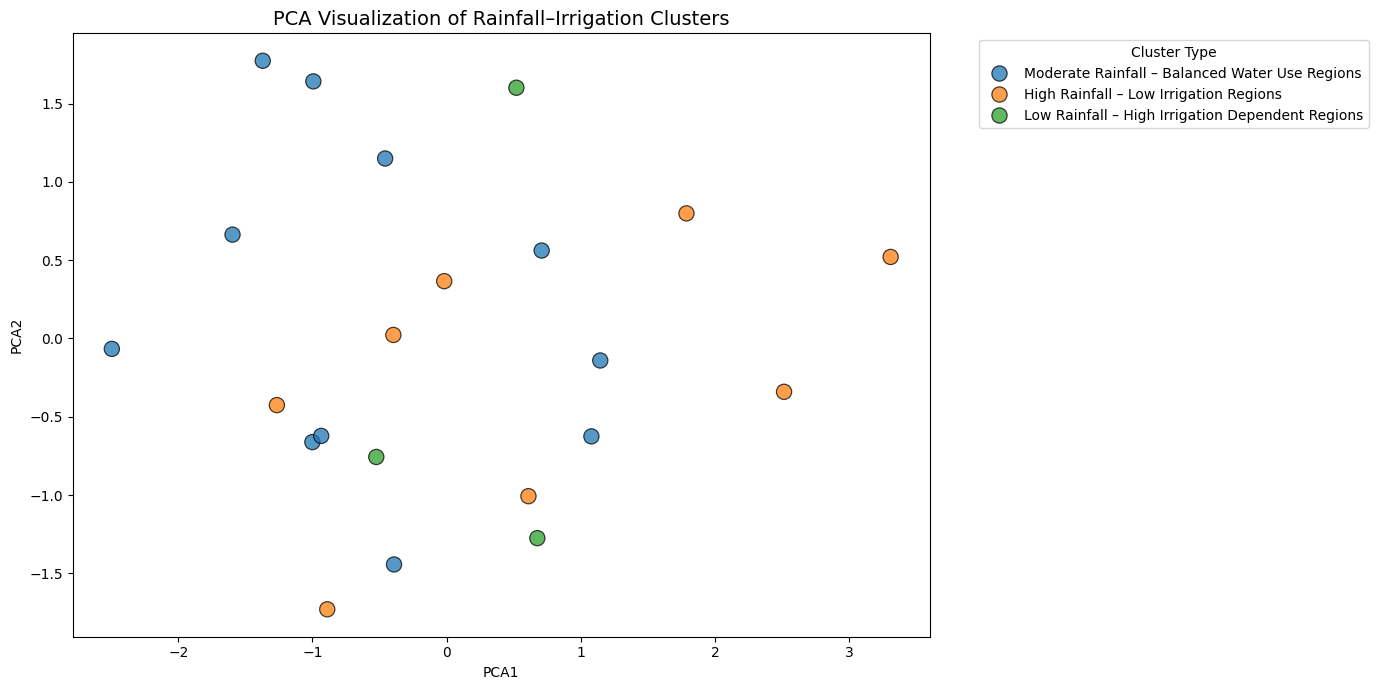

In [ ]:
# 10
plt.figure(figsize=(14, 7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster_Name',
    data=df,
    s=120,          # bigger points
    alpha=0.75,     # transparency to reduce crowding
    edgecolor='black'
)

plt.title('PCA Visualization of Rainfall–Irrigation Clusters', fontsize=14)
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# Move legend outside
plt.legend(
    title='Cluster Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


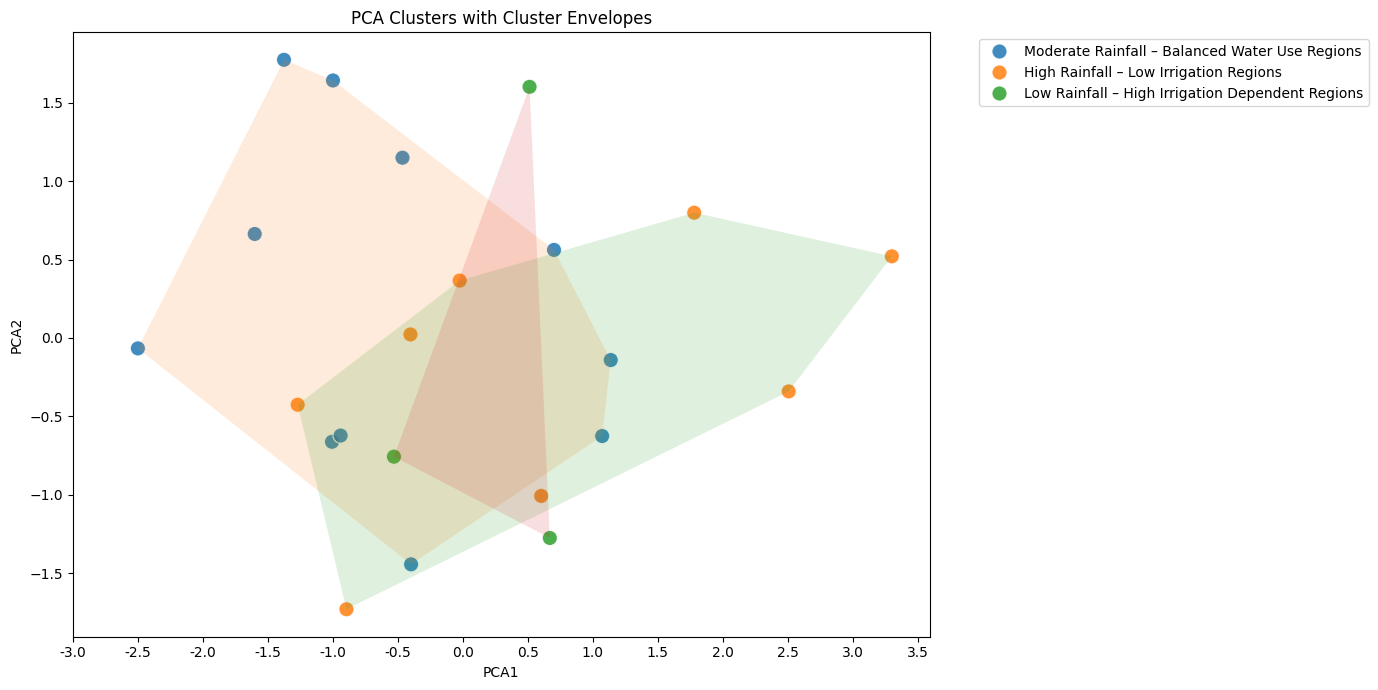

In [ ]:
#11
plt.figure(figsize=(14,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster_Name',
    data=df,
    s=120,
    alpha=0.85
)

from scipy.spatial import ConvexHull

for name in df['Cluster_Name'].unique():
    subset = df[df['Cluster_Name'] == name][['PCA1','PCA2']].values
    if len(subset) >= 3:
        hull = ConvexHull(subset)
        plt.fill(
            subset[hull.vertices, 0],
            subset[hull.vertices, 1],
            alpha=0.15
        )

plt.xticks(np.arange(
    df['PCA1'].min() - 0.5,
    df['PCA1'].max() + 0.5,
    0.5
))
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA Clusters with Cluster Envelopes")
plt.tight_layout()
plt.show()


In [ ]:
# 12
centroids = kmeans.cluster_centers_

sample_index = df[df['Cluster'] == 1].index[0]
point = X_all_scaled[sample_index]


distances = np.linalg.norm(centroids - point, axis=1)

print("Distances to centroids:", distances)
print("Closest centroid:", np.argmin(distances))


Distances to centroids: [1.05367681 1.94059861 4.10227142]
Closest centroid: 0


In [ ]:
# 13
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_scaled)

df.loc[X_train.index, 'Anomaly'] = iso.predict(X_train_scaled)
df.loc[X_test.index, 'Anomaly'] = iso.predict(X_test_scaled)



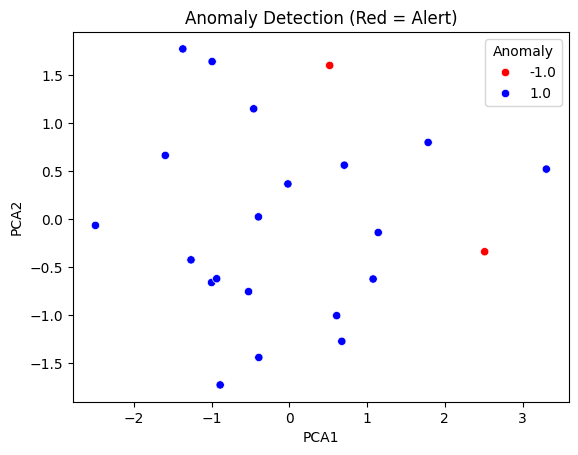

In [ ]:
# 14
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Anomaly',
    data=df,
    palette={1: 'blue', -1: 'red'}
)
plt.title('Anomaly Detection (Red = Alert)')
plt.show()


In [ ]:
anomalous_regions = df[df['Anomaly'] == -1]['District']

print("Regions showing anomalous rainfall–irrigation patterns:")
for region in anomalous_regions:
    print("-", region)


Regions showing anomalous rainfall–irrigation patterns:
- Ludhiana
- Pathankot


In [ ]:
# 15
import random

# Randomly select one region
random_index = random.choice(df.index)

sample = df.loc[[random_index], features]
sample_scaled = scaler.transform(sample)

cluster_pred = kmeans.predict(sample_scaled)[0]
anomaly_pred = iso.predict(sample_scaled)[0]

print("Selected Region:", df.loc[random_index, 'District'])
print("Cluster:", df.loc[random_index, 'Cluster_Name'])
print("Status:", "ALERT -> This region behaves unusually compared to others."
      if anomaly_pred == -1 else "Normal -> Regions show typical rainfall–irrigation behavior and do not require immediate intervention.")

Selected Region: Fazilka
Cluster: High Rainfall – Low Irrigation Regions
Status: Normal -> Regions show typical rainfall–irrigation behavior and do not require immediate intervention.
